# 실험 — y 없이 군집화하면 데이터는 몇 덩어리로 나뉘는가

지금 진단 모델은 **돌봄부담을 5구간으로 맞히는 지도학습**이고 macro F1 이 0.34다.
낮다. 그런데 애초에 **5구간이라는 구분이 데이터의 실제 구조와 맞는지**는 아무도 확인하지 않았다.

이 노트북은 **정답(`care_burden`)을 빼고** 38개 설명변수만으로 군집화해서 세 가지를 본다.

1. 데이터가 자연스럽게 몇 덩어리로 나뉘는가 — **5개가 맞나?**
2. 그 덩어리가 `care_burden` 1~5 와 **얼마나 겹치나**
3. 겹치지 않는다면 → 성능이 낮은 이유가 **모델이 아니라 문제 정의**에 있을 수 있다

## 안전 선언

- **DB 는 읽기만 한다.** `v_cb_tree_v1` 조회 외에 어떤 쓰기도 하지 않는다.
- **`models/` 를 건드리지 않는다.** 가동 중인 홈페이지에 영향이 없다.
- **test 602건을 쓰지 않는다.** train 2,398건만 본다.
- 이 폴더(`~/project2608-exp`, 브랜치 `exp/h`)는 `main` 과 물리적으로 분리돼 있다.

## 1. 준비

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

def load_env():
    for d in (ROOT, *ROOT.parents):
        p = d / '.env'
        if p.is_file():
            for line in p.read_text(encoding='utf-8').splitlines():
                line = line.strip()
                if line and not line.startswith('#') and '=' in line:
                    k, v = line.split('=', 1)
                    os.environ.setdefault(k.strip(), v.strip().strip('\'"'))
            return p
print('.env :', load_env())

import numpy as np, pandas as pd, pymysql
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

_inst = {f.name for f in font_manager.fontManager.ttflist}
for c in ['AppleGothic','Apple SD Gothic Neo','NanumGothic','Malgun Gothic']:
    if c in _inst: mpl.rcParams['font.family'] = c; break
mpl.rcParams['axes.unicode_minus'] = False
SURFACE, INK1, INK2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e6e5e1', '#c8c7c2'
BURDEN = {1:'#801e1e',2:'#a92e2d',3:'#d04442',4:'#dd7170',5:'#e99b9a'}
NAME   = {1:'최고부담군',2:'고부담군',3:'중간부담군',4:'저부담군',5:'부담 없음'}
CAT1, CAT2, CAT3 = '#2a78d6', '#eb6834', '#8a8a86'
mpl.rcParams.update({'figure.facecolor':SURFACE,'axes.facecolor':SURFACE,'savefig.facecolor':SURFACE,
                     'figure.dpi':110,'font.size':10,'axes.titlesize':12,'axes.titleweight':'bold',
                     'axes.titlecolor':INK1,'axes.labelcolor':INK2,'text.color':INK1,
                     'xtick.color':INK2,'ytick.color':INK2})
def style(ax, grid='y'):
    ax.set_axisbelow(True)
    if grid: ax.grid(axis=grid, color=GRID, lw=0.8, zorder=0)
    for s in ('top','right'): ax.spines[s].set_visible(False)
    for s in ('left','bottom'): ax.spines[s].set_color(AXIS); ax.spines[s].set_linewidth(0.8)
    ax.tick_params(length=0); return ax
SEED = 20260901
print('준비 완료')

.env : /Users/pioneer3/project2608-exp/.env


준비 완료


## 2. 데이터 적재 — 정답은 따로 치워둔다

`care_burden` 을 읽기는 하지만 **군집화에는 넣지 않는다.** 마지막에 "군집이 부담 구간과
겹치는가"를 채점할 때만 쓴다. 이것이 이 실험의 핵심 규칙이다.

In [2]:
con = pymysql.connect(host=os.environ['DB_HOST'], port=int(os.environ['DB_PORT']),
                      user=os.environ['DB_USER'], password=os.environ['DB_PASSWORD'],
                      database=os.environ['DB_NAME'], charset='utf8mb4')
meta = pd.read_sql('SELECT feature, var_scale, n_levels FROM cb_feature_meta_v1 ORDER BY feature', con)
feats = meta['feature'].tolist()
cols = ', '.join(f'`{f}`' for f in feats)
df = pd.read_sql(f"SELECT care_burden, {cols} FROM v_cb_tree_v1 WHERE split='train' ORDER BY row_id", con)
con.close()

y = df['care_burden'].values                 # ← 채점용으로만 보관
X = df[feats].fillna(-1)                     # 결측은 -1 = "해당 없음" 이라는 하나의 범주
print(f'train {len(df):,}건 · 설명변수 {len(feats)}개')
print('변수 유형 :', meta['var_scale'].value_counts().to_dict())
print()
print('y 는 아래 채점 단계까지 사용하지 않는다. 군집화 입력은 X 뿐이다.')

train 2,398건 · 설명변수 38개
변수 유형 : {'binary': 13, 'ordinal': 12, 'nominal': 9, 'continuous': 4}

y 는 아래 채점 단계까지 사용하지 않는다. 군집화 입력은 X 뿐이다.


/var/folders/q6/tjwyx9fx6rzd750055qzmw9h0000gs/T/ipykernel_14930/1591782969.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  meta = pd.read_sql('SELECT feature, var_scale, n_levels FROM cb_feature_meta_v1 ORDER BY feature', con)
/var/folders/q6/tjwyx9fx6rzd750055qzmw9h0000gs/T/ipykernel_14930/1591782969.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT care_burden, {cols} FROM v_cb_tree_v1 WHERE split='train' ORDER BY row_id", con)


## 3. 전처리 — 전부 원-핫

38개 변수를 모두 원-핫으로 편다. 이유는 두 가지다.

- **결측(-1)이 하나의 범주로 살아난다.** 이 데이터의 결측은 누락이 아니라 분기 문항의
  "해당 없음"이므로 정보다. 대치하면 훼손된다.
- **척도가 뒤섞인 변수들을 같은 자로 잰다.** 나이(78레벨)와 성별(2레벨)을 그대로 두면
  거리 계산이 나이에 지배된다.

원-핫 뒤 PCA 로 차원을 줄여 군집화한다.

findfont: Failed to find font weight bold, now using 400.


원-핫 : 38변수 → 326열
설명분산 80% 까지 44개 성분 · 90% 까지 72개


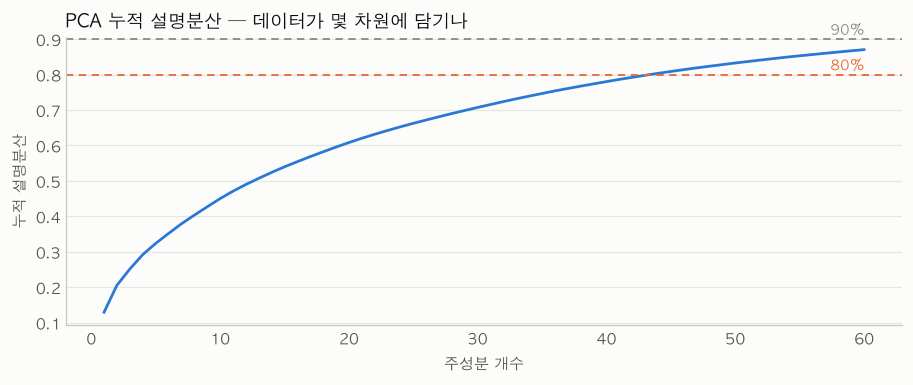

군집화 입력 : 2398건 × 44차원

첫 성분이 설명하는 분산이 작으면, 이 데이터에 뚜렷한 축이 없다는 뜻이다.
  1번 성분 12.9% · 2번 7.6% · 3번 4.6%


In [3]:
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
Xo = enc.fit_transform(X)
print(f'원-핫 : {X.shape[1]}변수 → {Xo.shape[1]}열')

pca_full = PCA(random_state=SEED).fit(Xo)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n80 = int(np.argmax(cum >= 0.80)) + 1
n90 = int(np.argmax(cum >= 0.90)) + 1
print(f'설명분산 80% 까지 {n80}개 성분 · 90% 까지 {n90}개')

fig, ax = plt.subplots(figsize=(8.4, 3.6)); style(ax)
ax.plot(range(1, 61), cum[:60], color=CAT1, lw=1.8)
for v, c, t in [(0.80, CAT2, '80%'), (0.90, CAT3, '90%')]:
    ax.axhline(v, color=c, lw=1.2, ls=(0,(4,3)))
    ax.annotate(t, (60, v), fontsize=9, color=c, va='bottom', ha='right')
ax.set_xlabel('주성분 개수'); ax.set_ylabel('누적 설명분산')
ax.set_title('PCA 누적 설명분산 — 데이터가 몇 차원에 담기나', loc='left')
fig.tight_layout(); plt.show()

Z = PCA(n_components=n80, random_state=SEED).fit_transform(Xo)
print(f'군집화 입력 : {Z.shape[0]}건 × {Z.shape[1]}차원')
print()
print('첫 성분이 설명하는 분산이 작으면, 이 데이터에 뚜렷한 축이 없다는 뜻이다.')
print(f'  1번 성분 {pca_full.explained_variance_ratio_[0]*100:.1f}% · '
      f'2번 {pca_full.explained_variance_ratio_[1]*100:.1f}% · '
      f'3번 {pca_full.explained_variance_ratio_[2]*100:.1f}%')

## 4. 몇 덩어리로 나뉘는가 — k 탐색

**실루엣 계수**로 잰다. 각 점이 "자기 군집에 얼마나 잘 붙어 있고 이웃 군집에서 얼마나 떨어져
있는지"를 −1~1 로 나타낸 값이다.

| 실루엣 | 해석 |
|---|---|
| 0.7 이상 | 뚜렷하게 나뉜다 |
| 0.5 ~ 0.7 | 합리적인 구조 |
| 0.25 ~ 0.5 | 약하다. 구조가 있다고 보기 어렵다 |
| 0.25 미만 | **뚜렷한 군집 구조가 없다** |

,실루엣,관성(inertia)
k,,
2,0.1233,34012.6887
3,0.1153,31352.6295
4,0.1075,29685.9188
5,0.1090,28689.0034
6,0.1034,27870.6035
7,0.1000,27066.8422
8,0.1064,26368.8601
9,0.0999,25766.8428
10,0.0944,25395.0621


findfont: Failed to find font weight bold, now using 400.


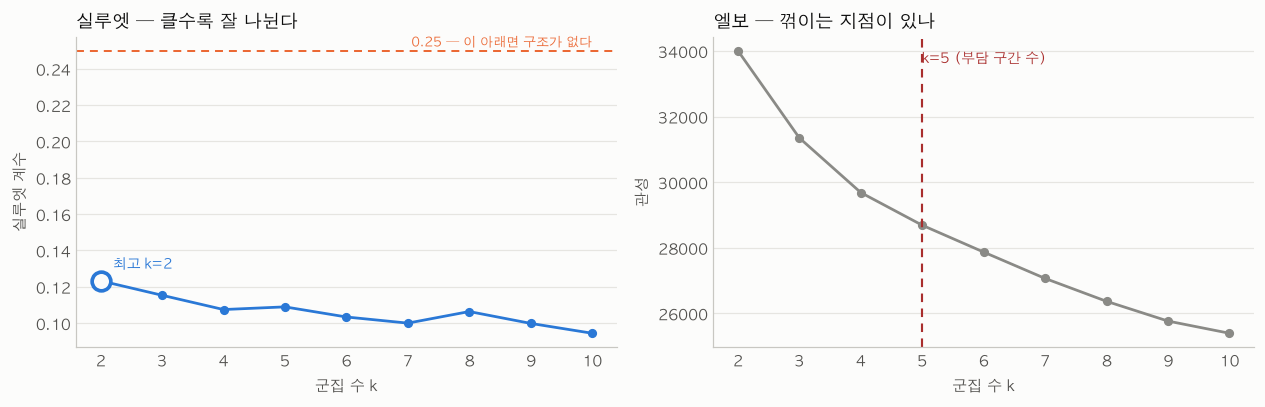

실루엣 최고 : k=2 (0.1233)
k=5 일 때  : 0.1090


In [4]:
ks = range(2, 11)
sil, inertia = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Z)
    sil.append(silhouette_score(Z, km.labels_, random_state=SEED))
    inertia.append(km.inertia_)
res = pd.DataFrame({'k': list(ks), '실루엣': sil, '관성(inertia)': inertia}).set_index('k')
display(res.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.8))
ax = style(axes[0])
ax.plot(list(ks), sil, color=CAT1, lw=1.8, marker='o', ms=5)
ax.axhline(0.25, color=CAT2, lw=1.3, ls=(0,(4,3)))
ax.annotate('0.25 — 이 아래면 구조가 없다', (10, 0.25), fontsize=8.5, color=CAT2, va='bottom', ha='right')
best_k = int(res['실루엣'].idxmax())
ax.scatter([best_k],[res.loc[best_k,'실루엣']], s=150, facecolor=SURFACE, edgecolor=CAT1, lw=2.4, zorder=5)
ax.annotate(f'최고 k={best_k}', (best_k, res.loc[best_k,'실루엣']), textcoords='offset points',
            xytext=(8,8), fontsize=9, color=CAT1, fontweight='bold')
ax.set_xlabel('군집 수 k'); ax.set_ylabel('실루엣 계수'); ax.set_title('실루엣 — 클수록 잘 나뉜다', loc='left')

ax = style(axes[1])
ax.plot(list(ks), inertia, color=CAT3, lw=1.8, marker='o', ms=5)
ax.axvline(5, color=BURDEN[2], lw=1.4, ls=(0,(4,3)))
ax.annotate('k=5 (부담 구간 수)', (5, max(inertia)), fontsize=9, color=BURDEN[2], va='top')
ax.set_xlabel('군집 수 k'); ax.set_ylabel('관성'); ax.set_title('엘보 — 꺾이는 지점이 있나', loc='left')
fig.tight_layout(); plt.show()

print(f'실루엣 최고 : k={best_k} ({res["실루엣"].max():.4f})')
print(f'k=5 일 때  : {res.loc[5,"실루엣"]:.4f}')

## 5. 핵심 질문 — 군집이 부담 구간과 겹치는가

여기서 정답을 처음 꺼낸다. 두 지표로 잰다.

- **ARI** (조정 랜드 지수): 두 분할이 얼마나 같은가. 0 = 무작위와 다를 바 없음, 1 = 완전 일치
- **NMI** (정규화 상호정보량): 군집을 알면 부담 구간을 얼마나 알 수 있나. 0~1

,ARI,NMI,실루엣
k,,,
2,0.0308,0.0322,0.1233
3,0.0206,0.0283,0.1153
4,0.0306,0.0520,0.1075
5,0.0269,0.0464,0.1090
6,0.0195,0.0411,0.1034
7,0.0214,0.0393,0.1000
8,0.0215,0.0395,0.1064
9,0.0126,0.0382,0.0999
10,0.0157,0.0396,0.0944


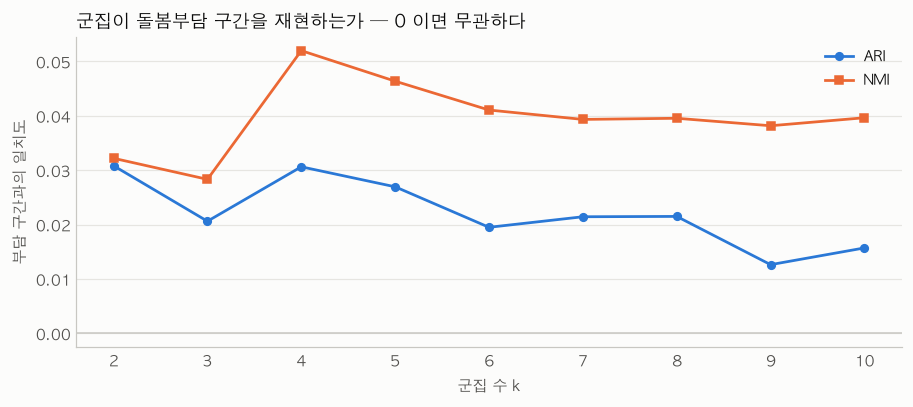


k=5 교차표 — 행이 군집, 열이 실제 부담 구간


부담 구간,최고부담군,고부담군,중간부담군,저부담군,부담 없음
군집,,,,,
0,55,142,150,36,14
1,76,199,173,59,9
2,51,217,255,155,30
3,25,88,65,35,6
4,164,286,89,17,2


행 기준 비율 (%) — 각 군집이 어느 구간으로 이루어졌나


부담 구간,최고부담군,고부담군,중간부담군,저부담군,부담 없음
군집,,,,,
0,13.9,35.8,37.8,9.1,3.5
1,14.7,38.6,33.5,11.4,1.7
2,7.2,30.6,36.0,21.9,4.2
3,11.4,40.2,29.7,16.0,2.7
4,29.4,51.3,15.9,3.0,0.4



ARI 0.0269 · NMI 0.0464
전체 분포와 비교 : {'최고부담군': '15.5%', '고부담군': '38.9%', '중간부담군': '30.5%', '저부담군': '12.6%', '부담 없음': '2.5%'}


In [5]:
rows = []
for k in ks:
    lab = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(Z)
    rows.append({'k': k, 'ARI': adjusted_rand_score(y, lab), 'NMI': normalized_mutual_info_score(y, lab),
                 '실루엣': silhouette_score(Z, lab, random_state=SEED)})
agree = pd.DataFrame(rows).set_index('k')
display(agree.round(4))

fig, ax = plt.subplots(figsize=(8.4, 3.8)); style(ax)
ax.plot(agree.index, agree['ARI'], color=CAT1, lw=1.8, marker='o', ms=5, label='ARI')
ax.plot(agree.index, agree['NMI'], color=CAT2, lw=1.8, marker='s', ms=5, label='NMI')
ax.axhline(0, color=AXIS, lw=1)
ax.set_xlabel('군집 수 k'); ax.set_ylabel('부담 구간과의 일치도')
ax.set_title('군집이 돌봄부담 구간을 재현하는가 — 0 이면 무관하다', loc='left')
ax.legend(frameon=False, fontsize=9); fig.tight_layout(); plt.show()

k5 = KMeans(n_clusters=5, random_state=SEED, n_init=10).fit_predict(Z)
ct = pd.crosstab(pd.Series(k5, name='군집'), pd.Series([NAME[v] for v in y], name='부담 구간'))
ct = ct[[NAME[i] for i in [1,2,3,4,5]]]
print('\nk=5 교차표 — 행이 군집, 열이 실제 부담 구간')
display(ct)
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)
print('행 기준 비율 (%) — 각 군집이 어느 구간으로 이루어졌나')
display(pct)
print(f"\nARI {adjusted_rand_score(y,k5):.4f} · NMI {normalized_mutual_info_score(y,k5):.4f}")
print('전체 분포와 비교 :', {NAME[i]: f'{(y==i).mean()*100:.1f}%' for i in [1,2,3,4,5]})

## 6. 2차원으로 펼쳐 보기

findfont: Failed to find font weight bold, now using 400.


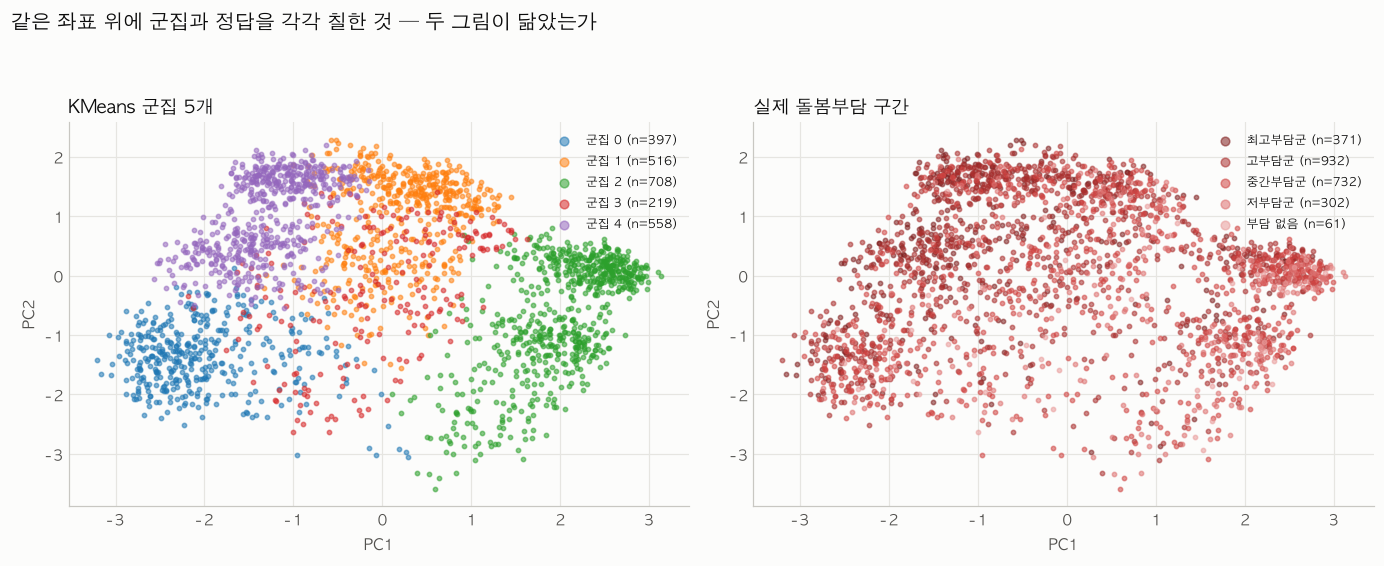

In [6]:
Z2 = PCA(n_components=2, random_state=SEED).fit_transform(Xo)
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.2))
ax = style(axes[0], grid=None); ax.grid(color=GRID, lw=0.8)
for c in range(5):
    m = k5 == c
    ax.scatter(Z2[m,0], Z2[m,1], s=8, alpha=0.55, label=f'군집 {c} (n={m.sum()})')
ax.set_title('KMeans 군집 5개', loc='left'); ax.legend(frameon=False, fontsize=8, markerscale=2)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

ax = style(axes[1], grid=None); ax.grid(color=GRID, lw=0.8)
for lv in [1,2,3,4,5]:
    m = y == lv
    ax.scatter(Z2[m,0], Z2[m,1], s=8, alpha=0.55, color=BURDEN[lv], label=f'{NAME[lv]} (n={m.sum()})')
ax.set_title('실제 돌봄부담 구간', loc='left'); ax.legend(frameon=False, fontsize=8, markerscale=2)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
fig.suptitle('같은 좌표 위에 군집과 정답을 각각 칠한 것 — 두 그림이 닮았는가',
             x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.93]); plt.show()

## 7. 군집들은 무엇으로 갈렸나

부담 구간과 겹치지 않는다면, **무엇을 기준으로 갈린 것인지**를 봐야 한다.
군집별로 각 변수의 평균을 전체 평균과 비교해 차이가 큰 것부터 본다.

군집,전체평균,0,1,2,3,4
caregiver_age,58.80,60.16,54.01,58.86,60.71,61.44
age_disability_suspected,5.67,10.17,3.96,5.60,7.03,3.59
last_job_quit_reason,-0.10,0.42,-1.00,-1.00,6.22,-0.97
wants_person_employed,1.48,2.87,2.04,-1.00,2.08,2.88
secondary_caregiver_type,3.35,6.59,2.15,2.79,3.57,2.79
severe_dd_job_willingness,0.25,1.48,-0.41,-1.00,-0.33,1.79
past_employment_exp,0.99,1.80,2.00,-1.00,1.00,2.00
family_support_for_employment,3.48,2.22,4.21,4.48,3.81,2.30
school_helpfulness,2.71,2.13,1.66,3.89,3.60,2.27
household_head_type,2.04,4.35,1.30,1.71,1.95,1.56


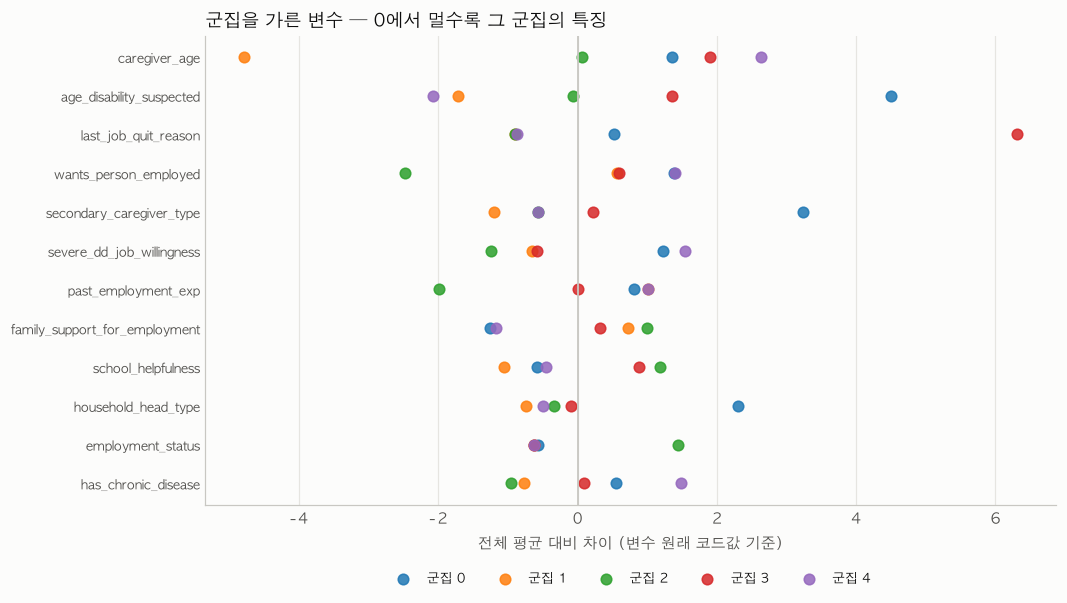

In [7]:
prof = X.copy(); prof['군집'] = k5
num = prof.groupby('군집')[feats].mean()
overall = X[feats].mean()
diff = (num - overall).abs().mean(axis=0).sort_values(ascending=False)
top = diff.head(12).index.tolist()

lab_kr = dict(zip(meta['feature'], meta['feature']))
show = num[top].T.copy()
show.insert(0, '전체평균', overall[top])
display(show.round(2))

fig, ax = plt.subplots(figsize=(9.8, 5.6)); style(ax, grid='x')
yp = np.arange(len(top))
for c in range(5):
    ax.scatter(num.loc[c, top] - overall[top], yp, s=48, alpha=0.85, label=f'군집 {c}')
ax.axvline(0, color=AXIS, lw=1.2)
ax.set_yticks(yp); ax.set_yticklabels(top, fontsize=8.8); ax.invert_yaxis()
ax.set_xlabel('전체 평균 대비 차이 (변수 원래 코드값 기준)')
ax.set_title('군집을 가른 변수 — 0에서 멀수록 그 군집의 특징', loc='left')
ax.legend(frameon=False, fontsize=8.5, ncol=5, loc='lower center', bbox_to_anchor=(0.5,-0.2))
fig.tight_layout(); plt.show()

---

## 정리

아래는 실행 결과를 보고 채워 넣을 자리다. 판정 기준만 미리 적어둔다.

| 관측 | 뜻 |
|---|---|
| 실루엣이 어느 k 에서도 **0.25 미만** | 이 데이터에 뚜렷한 덩어리 구조가 없다. 연속적으로 퍼져 있다 |
| **ARI 가 0 근처** | 군집이 돌봄부담 구간과 무관하다. 데이터가 스스로 나뉘는 축은 부담이 아닌 다른 것이다 |
| 실루엣 최고 k 가 **5가 아님** | 5구간이라는 구분은 데이터 구조가 아니라 **설문 척도에서 온 것**이다 |

셋 다 해당한다면 결론은 이렇다.

> **macro F1 0.34 는 모델이 못해서가 아니라, 38개 설명변수가 돌봄부담을 5구간으로 가를 만큼의
> 정보를 담고 있지 않기 때문이다.** 알고리즘을 바꿔도 크게 오르지 않는다.

이 경우 성능을 올리는 길은 모델 교체가 아니라 **문제를 다시 정의하는 것**이다 —
5구간 대신 2구간(고부담 여부)으로 좁히면 실제로 정확도가 0.43에서 0.67로 오른다.

## 이 노트북이 하지 않은 것

- **DB 에 쓰지 않았다.** 조회만 했다.
- **`models/` 를 건드리지 않았다.** 가동 중인 홈페이지와 무관하다.
- **test 602건을 쓰지 않았다.**